In [1]:
import falnama as fn
import matplotlib.pyplot as plt
import maxrf4u as mx  
import moseley as mos
import numpy as np
import scipy.signal as ssg 
import matplotlib.cm as cm
import skimage.exposure as ske
from matplotlib.patches import Rectangle

In [2]:
def plot_element_lines(element, y=None, ax=None, exc_keV=23, color=None, x_keVs=None): 
    '''Add emission lines to spectral plot. '''

    if ax == None: 
        fig, ax = plt.subplots(figsize=[15, 5])
        
    if color == None: 
        color = mx.colorize(element)
    
    elem_y = mx.get_element_spectrum(element, exc_keV, x_keVs=x_keVs)
    peak_idxs = ssg.find_peaks(elem_y)[0]
    peak_idxs = np.array([int(idx) for idx in peak_idxs])
    peaks_x = x_keVs[peak_idxs]
    peaks_y = elem_y[peak_idxs] 

    sort_idxs = np.argsort(peaks_y)
    peak_idxs_sorted = peak_idxs[sort_idxs][::-1] 

    if y is not None: 
        alpha_idx = peak_idxs_sorted[0]
        y_alpha  = y[alpha_idx]
        peaks_y = peaks_y * y_alpha
    
    ax.vlines(peaks_x, np.zeros_like(peaks_y), peaks_y, color=color)
    ax.scatter(peaks_x, peaks_y, marker='s', s=8, color=color)
    
    for x, y in zip(peaks_x, peaks_y): 
        ax.annotate(element, [x-0.1, y + 2], color=color) 

    return peak_idxs_sorted

In [3]:
print(f'falnama: {fn.__version__}\nmaxrf4u: {mx.__version__}') 

falnama: 0.0.1
maxrf4u: 0.1.42


In [4]:
data = fn.Falnama_maxrf_data()

data.get_base_path()

datastack_files = data.get_datastack_files()
datastack_files

['/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-01_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-03_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-08_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-10_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-12_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-13_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-17_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-18_400_300_50_det.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project

In [8]:
%matplotlib inline

In [9]:
imvis_list = []
extent_list = []
for datastack_file in datastack_files: 
    ds = mx.DataStack(datastack_file)
    im = ds.read('imvis_reg')
    extent = ds.read('imvis_extent')
    imvis_list.append(im)
    extent_list.append(extent)

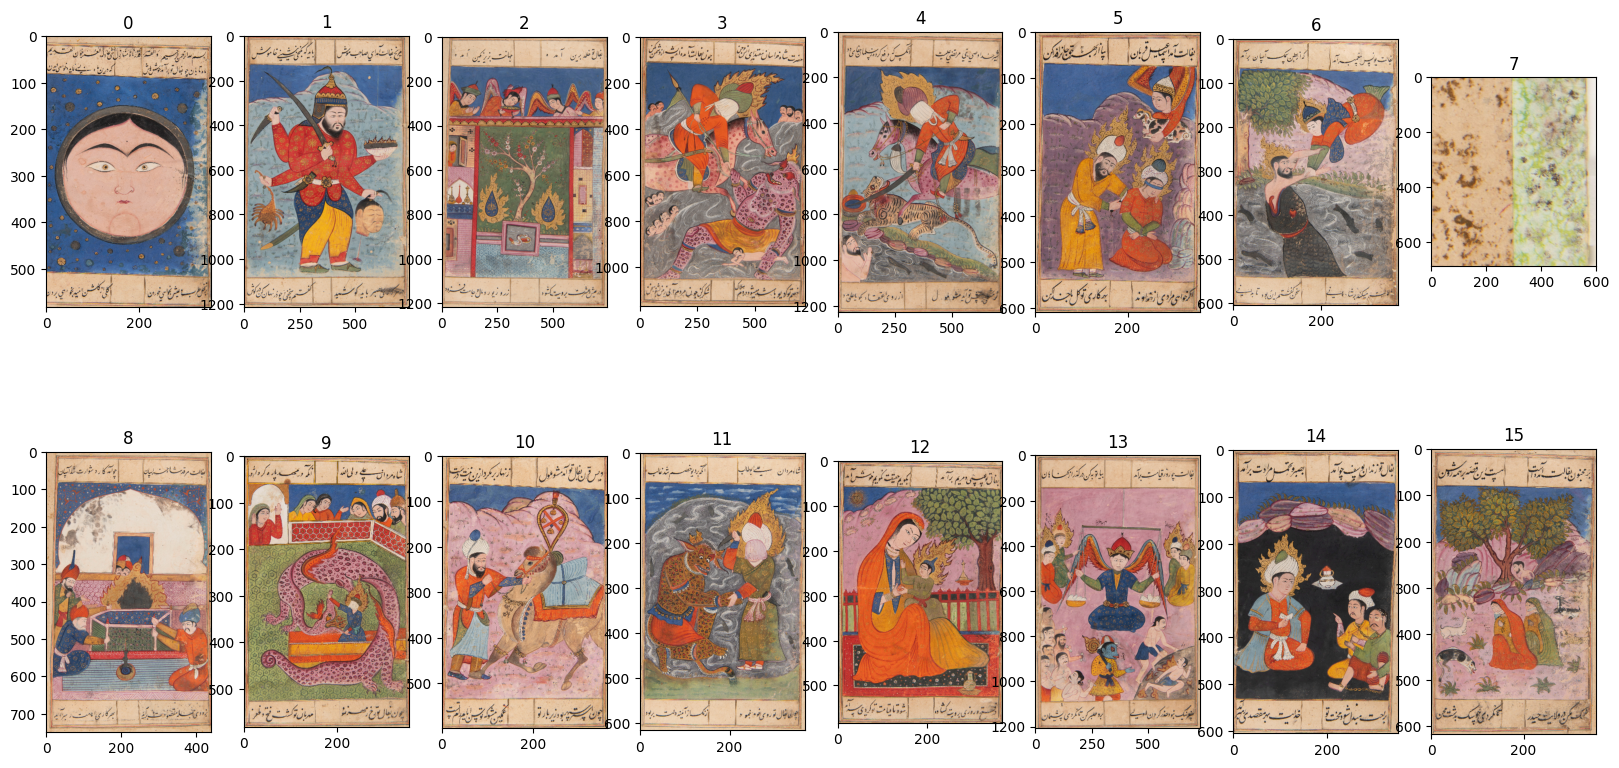

In [11]:
fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[20, 10])
axs = axs.flatten()
for i, [im, ax, extent] in enumerate(zip(imvis_list, axs, extent_list)): 
    ax.imshow(im, extent=extent)
    ax.set_title(i)

In [43]:
n = 15
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

cube = ds.read('maxrf_cube', compute=False)
imvis_highres = ds.read('imvis_reg_highres')
imvis = ds.read('imvis_reg')
extent = ds.read('imvis_extent')
x_keVs = ds.read('maxrf_energies')
y_maxspectrum = ds.read('maxrf_maxspectrum')

ds.tree()

/
├── compton_peak_energy (1,) float64
├── hotmax_baselines (31, 4096) float64
├── hotmax_noiselines (31, 4096) float64
├── hotmax_peak_idxs_flat (34,) int64
├── hotmax_peak_idxs_list (31, 2) int64
├── hotmax_spectra (31, 4096) float32
├── hotmax_spots (31, 2) int64
├── hotmax_subpeak_idxs_list (31, 18) int64
├── imvis_extent (4,) int64
├── imvis_reg (617, 357, 3) uint8
├── imvis_reg_highres (8256, 4777, 3) uint8
├── maxrf_cube (617, 357, 4096) float32
├── maxrf_energies (4096,) float64
├── maxrf_maxspectrum (4096,) float32
├── maxrf_sumspectrum (4096,) float64
├── nmf_atomnums (18,) int64
├── nmf_elementmaps (18, 617, 357) float32
├── nmf_gausscomponents (35, 4096) float32
├── nmf_peakmaps (35, 617, 357) float32
└── nmf_peaks2elements_matrix (18, 34) float32

/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-35_400_500_50.datastack:




In [9]:
%matplotlib inline

plt.close('all')

In [ ]:
# run this cell to create regions of interest
fig, axs = plt.subplots(ncols=3, figsize=[20, 8], squeeze=True)
for ax in axs: 
    ax.imshow(imvis_highres, extent=extent)

In [22]:
#xylims_list = [[int(ax.get_xlim()[0]), int(ax.get_xlim()[1]), int(ax.get_ylim()[0]), int(ax.get_ylim()[1])] for ax in axs]
xylims_list = [[140, 162, 464, 435], [137, 151, 398, 385], [250, 268, 461, 436]]

roi_cubes = [cube[l:k, i:j].compute() for i, j, k, l in xylims_list]

mean_spectra_list = [c.reshape([-1, 4096]).mean(axis=0) for c in roi_cubes]
max_spectra_list = [c.reshape([-1, 4096]).max(axis=0) for c in roi_cubes]
min_spectra_list = [c.reshape([-1, 4096]).min(axis=0) for c in roi_cubes]

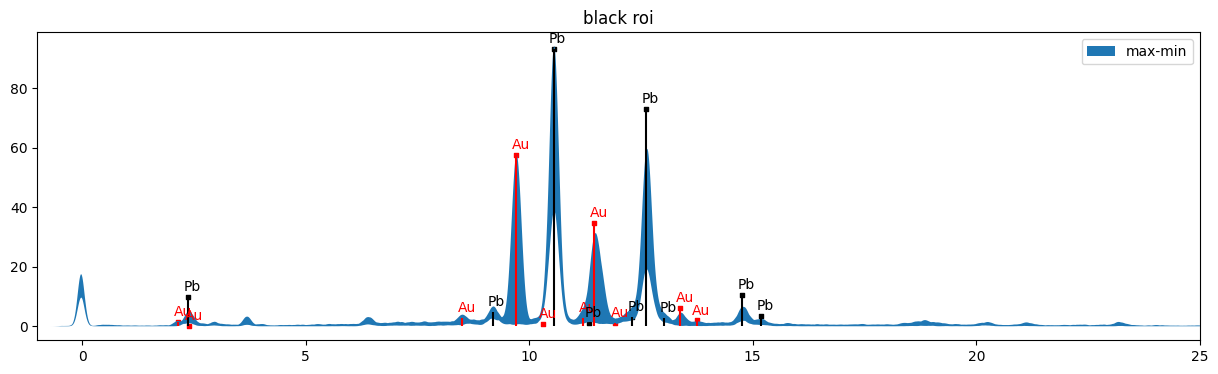

In [19]:
fig, ax = plt.subplots(figsize=[15, 4])

roi_n = 0

y_mean = mean_spectra_list[roi_n]
y_max = max_spectra_list[roi_n]
y_min = min_spectra_list[roi_n]

elem_idxs_dict = {}

for elem, color in zip(['Au', 'Pb'], ['r', 'k']): 
    idxs = plot_element_lines(elem, y=y_max, ax=ax, x_keVs=x_keVs, color=color)
    elem_idxs_dict[elem] = idxs 

ax.fill_between(x_keVs, y_max, y2=y_min, label='max-min')
ax.set_title('black roi')
ax.set_xlim([-1, 25]); 
ax.legend()

Text(0.5, 1.0, 'Pb_alpha: 10.54 keV')

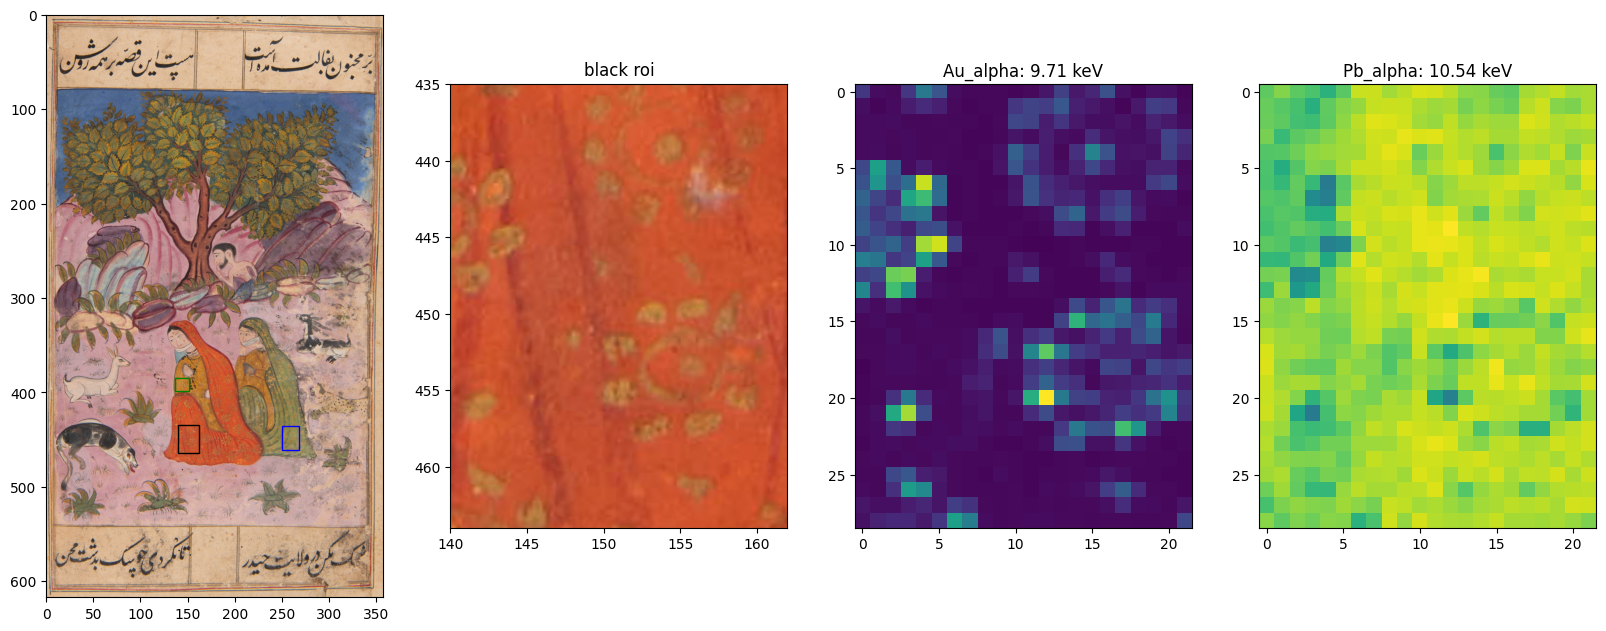

In [21]:
fig, axs = plt.subplots(ncols=4, figsize=[20, 8], squeeze=True)

edgecolors = ['k', 'g', 'b']

axs[0].imshow(imvis_highres, extent=extent)

for i, xylims in enumerate(xylims_list):
    x0, x1, y0, y1 = xylims
    axs[0].add_patch(Rectangle([x0, y1], x1 -x0, y0 - y1, linewidth=1, edgecolor=edgecolors[i], facecolor='none'))


axs[1].imshow(imvis_highres, extent=extent)
axs[1].set_xlim(xylims_list[roi_n][0:2])
axs[1].set_ylim(xylims_list[roi_n][2:4])
axs[1].set_title('black roi')

Au_alpha_map = cube_rois[roi_n][:,:, elem_idxs_dict['Au'][0]]
Pb_alpha_map = cube_rois[roi_n][:,:, elem_idxs_dict['Pb'][0]]

axs[2].imshow(Au_alpha_map, vmin=0)
axs[2].set_title(f'Au_alpha: {x_keVs[elem_idxs_dict['Au'][0]]:.02f} keV')

axs[3].imshow(Pb_alpha_map, vmin=0)
axs[3].set_title(f'Pb_alpha: {x_keVs[elem_idxs_dict['Pb'][0]]:.02f} keV')
    

In [23]:
roi_cube = roi_cubes[roi_n]
roi_cube.shape

(29, 22, 4096)

We need to locate the hotmax peaks in `y_max` 

In [35]:
peak_idxs, _ = ssg.find_peaks(y_max, prominence=1)
peak_idxs

array([  95,  336,  466,  736,  946, 1015, 1067, 1151, 1243, 1358, 1434,
       1572, 1978, 2410])

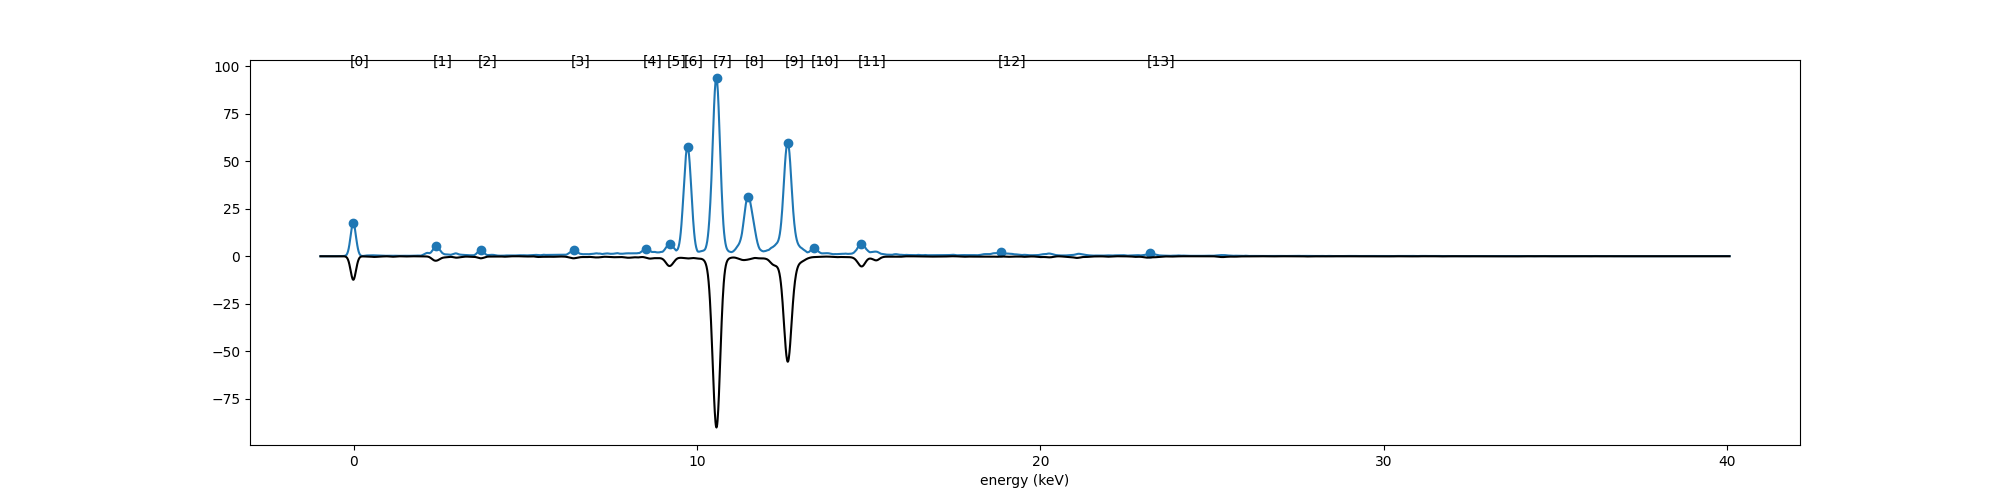

In [80]:
fig, ax = plt.subplots(figsize=[20, 5])
ax.plot(x_keVs, y_max)
ax.scatter(x_keVs[peak_idxs], y_max[peak_idxs])
for i, idx in enumerate(peak_idxs): 
    
    ax.annotate(f'[{i}]', [x_keVs[idx]-0.1, 100])
ax.set_xlabel('energy (keV)')

ax.plot(x_keVs, -roi_cube[i, j], color='k')

In [28]:
%matplotlib widget

In [79]:
elems = ['Pb', 'Au', 'Fe', 'Ca']
colors = ['k', 'orange', 'r', 'g']
idxs_list = []
for e, c in zip(elems, colors): 
    
    idxs = plot_element_lines(e, y=y_max, ax=ax, x_keVs=x_keVs, color=c)
    idxs_list.append(idxs)

Ok, we see that it is possible to explain all peaks in the max spectrum. Now let's improve this analysis by locating the hotmax pixels for the alpha peaks...

In [66]:
cube_slice = roi_cube[:,:, peak_idxs[7]]

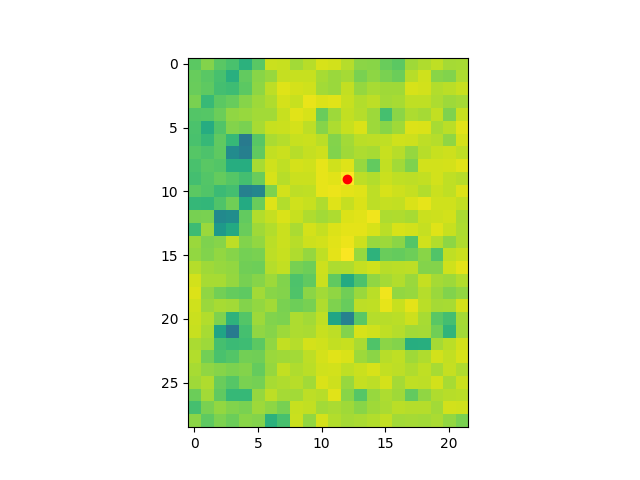

In [75]:
fig, ax = plt.subplots()
ax.imshow(cube_slice, vmin=0)
ax.scatter(j, i, color='r')

In [73]:
i, j = np.argwhere(cube_slice == cube_slice.max())[0]